In [56]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt
import matplotlib as mpl

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [57]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [58]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  
    "font.family": "serif",       
    "text.usetex": True,          
    "pgf.rcfonts": False,         
})

In [59]:
def basicColHist(df, var: str, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(df[var], bins=50, ax=ax)
    
    if title is None:
        title = f'{var} of BH-Sol systems at S1 SN'
    if xLabel is None:
        xLabel = var

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

def genVarHist(var: list, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(var, bins=50, ax=ax)
    
    if title is None:
        title = 'default'
    if xLabel is None:
        xLabel = 'default'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [60]:
def xVsY(
    xvar: str|list, yvar: str|list,
    df: pd.DataFrame | None = None,
    useDF: bool = True, 
    title: str | None = None,
    xLabel: str | None = None,
    yLabel: str | None = None,
    saveFig: bool = False,
    savePath: Path = Path(),
    fit: bool = False,
    ci: int = 95
) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))

    if useDF:
        x = df[xvar] if isinstance(xvar, str) else xvar
        y = df[yvar] if isinstance(yvar, str) else yvar
    else:
        x, y = xvar, yvar  
        
    if fit:
        sns.regplot(x=x, y=y, ci=ci, ax=ax,
                    line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
                    scatter_kws={"alpha": 0.6})
    else:
        sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)

    if title is None:
        if isinstance(xvar, str) and isinstance(yvar, str):
            title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
        else:
            title = 'Variable Comparison'

    if xLabel is None:
        xLabel = xvar if isinstance(xvar, str) else 'X-Axis'
        
    if yLabel is None:
        yLabel = yvar if isinstance(yvar, str) else 'Y-Axis'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [61]:

### sunlike
# pop = Population(str(DataPath / 'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
# bhSolRows = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')
# bhSolRows = bhSolRows.drop(17, axis='index')

####1d-01Zsun
# pop = Population(str(DataPath / '1e-01Zsun' / 'BH_Sol_Filtered_1e-01_Zsun_population.h5'))
# bhSolRows = pd.read_csv(DataPath /'1e-01Zsun' / 'BH_Sol_Filtered_1e-01_Zsun_population.csv')

####1d-02Zsun
pop = Population(str(DataPath / '1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_population.h5'))
bhSolRows = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_population.csv')


In [62]:
bhSolRows

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,59357,detached,NaN,4.047630e+09,97.168904,0.971643,NaN,step_SN,0.002903,BH,...,0.000000,NaN,0.000000,0.000000,0.729578,0.270282,0.750658,0.249173,0.238747,8.200427
1,97472,detached,CC2,9.927577e+08,2.521020,0.000000,-70.121475,step_CO_HMS_RLO,0.060651,BH,...,0.434087,0.010054,0.434087,0.008619,0.105575,0.162605,0.169017,0.830812,0.005156,19.502976
2,110308,detached,NaN,3.089658e+09,9.379683,0.563473,NaN,step_SN,0.003821,BH,...,0.000000,NaN,0.000000,0.000000,0.734717,0.265143,0.750658,0.249173,0.037925,1.320116
3,110579,detached,NaN,3.924980e+09,19.175381,0.702148,NaN,step_SN,0.003499,BH,...,0.000000,NaN,0.000000,0.000000,0.731028,0.268833,0.750658,0.249173,0.054968,1.888191
4,111457,detached,NaN,7.107143e+09,78.361189,0.933435,NaN,step_SN,0.001696,BH,...,0.000000,NaN,0.000000,0.000000,0.734089,0.265771,0.750658,0.249173,0.061059,2.119059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,956759,detached,NaN,2.824682e+09,1.275968,0.257787,NaN,step_SN,0.001217,BH,...,0.000000,NaN,0.000000,0.000000,0.742497,0.257357,0.750658,0.249173,0.021389,0.775549
71,968474,detached,CC2,7.039799e+09,3.019943,0.000000,-72.343714,step_CO_HMS_RLO,0.059923,BH,...,0.477034,0.010238,0.477034,0.008680,0.105203,0.135680,0.146021,0.853811,0.004736,17.034167
72,973142,detached,CC2,9.168883e+09,4.071618,0.000000,-83.419058,step_CO_HMS_RLO,0.059344,BH,...,0.447870,0.012106,0.447870,0.006267,0.044204,0.549033,0.204011,0.795814,0.003797,9.964024
73,979442,detached,NaN,1.657365e+09,33.500962,0.935945,NaN,step_SN,0.001712,BH,...,0.000000,NaN,0.000000,0.000000,0.728065,0.271796,0.750658,0.249173,0.186582,6.398517


In [63]:
pop.calculate_formation_channels()

In [64]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 56,
         'ZAMS_oCE1_CC1_oRLO2_CC2_FAILED': 7,
         'ZAMS_oCE1_CC1_END': 5,
         'ZAMS_oRLO1_CC1_oRLO2_oRLO2_CC2_END': 3,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_FAILED': 1,
         'ZAMS_oRLO1_CC1_oRLO2_FAILED_FAILED': 1,
         'ZAMS_CC1_oRLO2_CC2_FAILED': 1,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 1})

In [65]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [66]:
bhSolRows

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,59357,detached,NaN,4.047630e+09,97.168904,0.971643,NaN,step_SN,0.002903,BH,...,0.000000,NaN,0.000000,0.000000,0.729578,0.270282,0.750658,0.249173,0.238747,8.200427
1,97472,detached,CC2,9.927577e+08,2.521020,0.000000,-70.121475,step_CO_HMS_RLO,0.060651,BH,...,0.434087,0.010054,0.434087,0.008619,0.105575,0.162605,0.169017,0.830812,0.005156,19.502976
2,110308,detached,NaN,3.089658e+09,9.379683,0.563473,NaN,step_SN,0.003821,BH,...,0.000000,NaN,0.000000,0.000000,0.734717,0.265143,0.750658,0.249173,0.037925,1.320116
3,110579,detached,NaN,3.924980e+09,19.175381,0.702148,NaN,step_SN,0.003499,BH,...,0.000000,NaN,0.000000,0.000000,0.731028,0.268833,0.750658,0.249173,0.054968,1.888191
4,111457,detached,NaN,7.107143e+09,78.361189,0.933435,NaN,step_SN,0.001696,BH,...,0.000000,NaN,0.000000,0.000000,0.734089,0.265771,0.750658,0.249173,0.061059,2.119059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,956759,detached,NaN,2.824682e+09,1.275968,0.257787,NaN,step_SN,0.001217,BH,...,0.000000,NaN,0.000000,0.000000,0.742497,0.257357,0.750658,0.249173,0.021389,0.775549
71,968474,detached,CC2,7.039799e+09,3.019943,0.000000,-72.343714,step_CO_HMS_RLO,0.059923,BH,...,0.477034,0.010238,0.477034,0.008680,0.105203,0.135680,0.146021,0.853811,0.004736,17.034167
72,973142,detached,CC2,9.168883e+09,4.071618,0.000000,-83.419058,step_CO_HMS_RLO,0.059344,BH,...,0.447870,0.012106,0.447870,0.006267,0.044204,0.549033,0.204011,0.795814,0.003797,9.964024
73,979442,detached,NaN,1.657365e+09,33.500962,0.935945,NaN,step_SN,0.001712,BH,...,0.000000,NaN,0.000000,0.000000,0.728065,0.271796,0.750658,0.249173,0.186582,6.398517


In [67]:
pOneline[pOneline['S2_mass_i'] > 3]

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
1,detached,ZAMS,8.237533e+08,2289.225246,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.552143,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,0.01
13,detached,ZAMS,2.340302e+09,29.896324,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.039165,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,0.01
17,detached,ZAMS,1.134094e+09,9.982165,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.753367,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during MS,NaN,NaN,0,1,0.01
23,detached,ZAMS,2.468861e+09,2022.537812,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.171012,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,0.01
29,detached,ZAMS,8.453597e+09,29.635796,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.239887,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during MS,NaN,NaN,0,1,0.01
36,detached,ZAMS,7.349553e+09,29.635551,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,21.065241,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,0.01
39,detached,ZAMS,7.207660e+09,3325.780632,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,23.720180,...,stable_MT,NaN,NaN,no RLOF,Last stable RLOF during postMS,NaN,NaN,1,0,0.01
43,detached,ZAMS,6.724087e+09,26.475663,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.964135,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during MS,NaN,NaN,0,1,0.01
53,detached,ZAMS,5.341017e+09,2318.594804,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.158742,...,stable_MT,NaN,NaN,no RLOF,Last stable RLOF during postMS,NaN,NaN,1,1,0.01


In [68]:
print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & orbital\_period\_i \\
count & 75.000000 \\
mean & 2716.661836 \\
std & 770.775174 \\
min & 9.982165 \\
25\% & 2806.939187 \\
50\% & 2980.790142 \\
75\% & 3057.676091 \\
max & 3325.780632 \\
\end{tabular}



In [69]:
print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S2\_mass\_i \\
count & 75.000000 \\
mean & 2.964735 \\
std & 1.936867 \\
min & 1.551651 \\
25\% & 2.099869 \\
50\% & 2.412399 \\
75\% & 2.911162 \\
max & 15.543994 \\
\end{tabular}



In [70]:
print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S1\_mass\_i \\
count & 75.000000 \\
mean & 16.571340 \\
std & 1.549822 \\
min & 14.678809 \\
25\% & 15.587555 \\
50\% & 16.118006 \\
75\% & 17.279262 \\
max & 23.720180 \\
\end{tabular}



In [71]:
pOneline['eccentricity_f'].describe()

count    75.000000
mean      0.052126
std       0.197577
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.914504
Name: eccentricity_f, dtype: float64

In [72]:
graphSave = Path.cwd().parent / 'Reports' /'3_23_26' / 'graphs'

In [85]:
# basicColHist(pOneline, 'eccentricity_i')

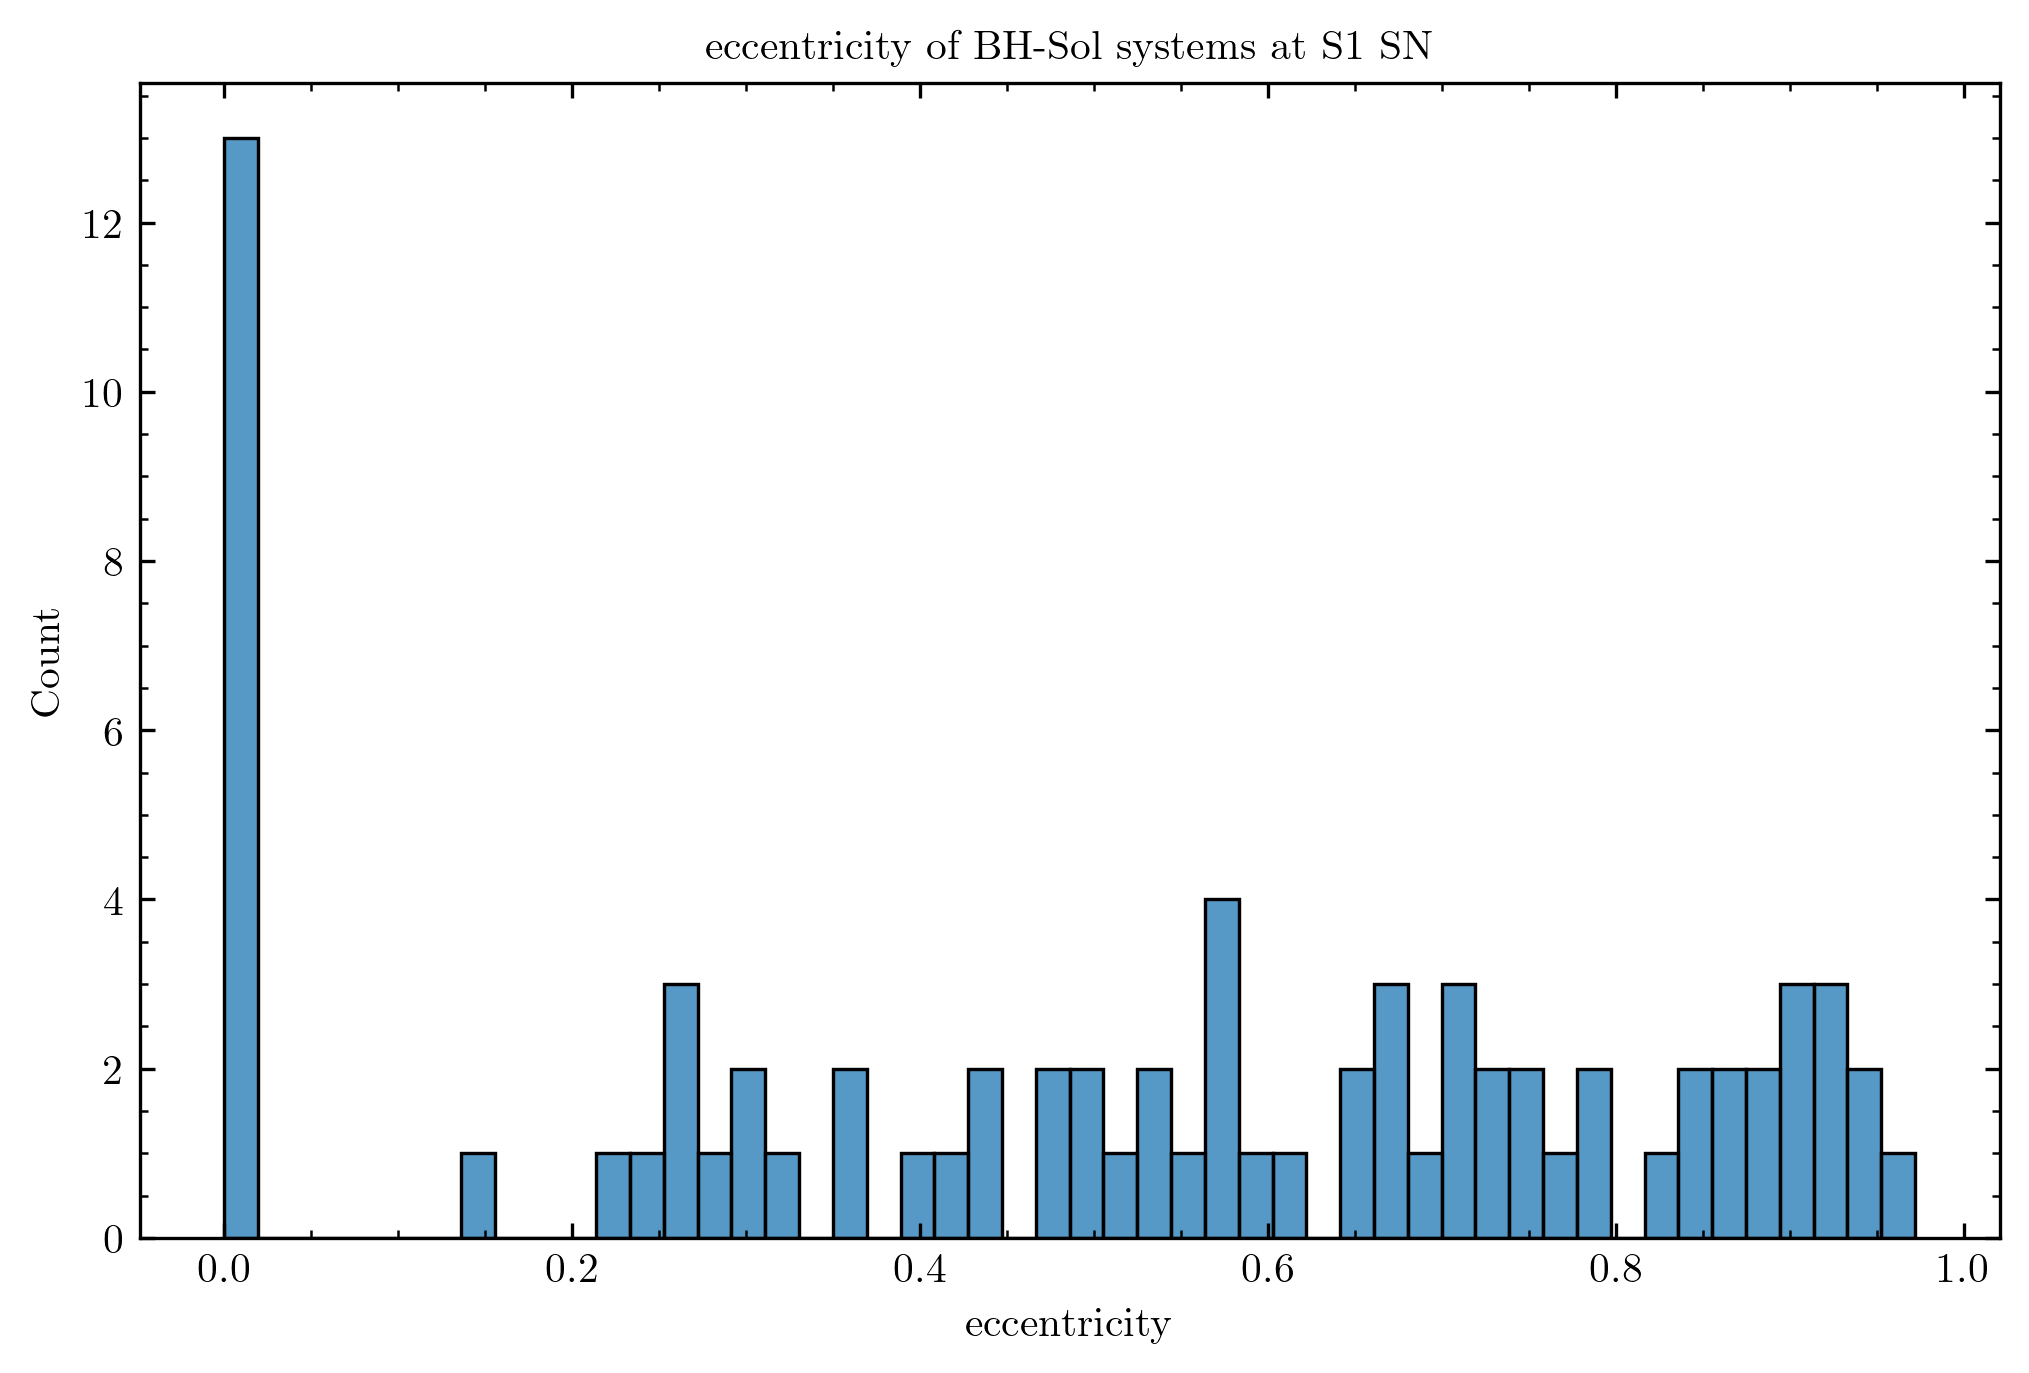

In [86]:
basicColHist(bhSolRows, 'eccentricity')

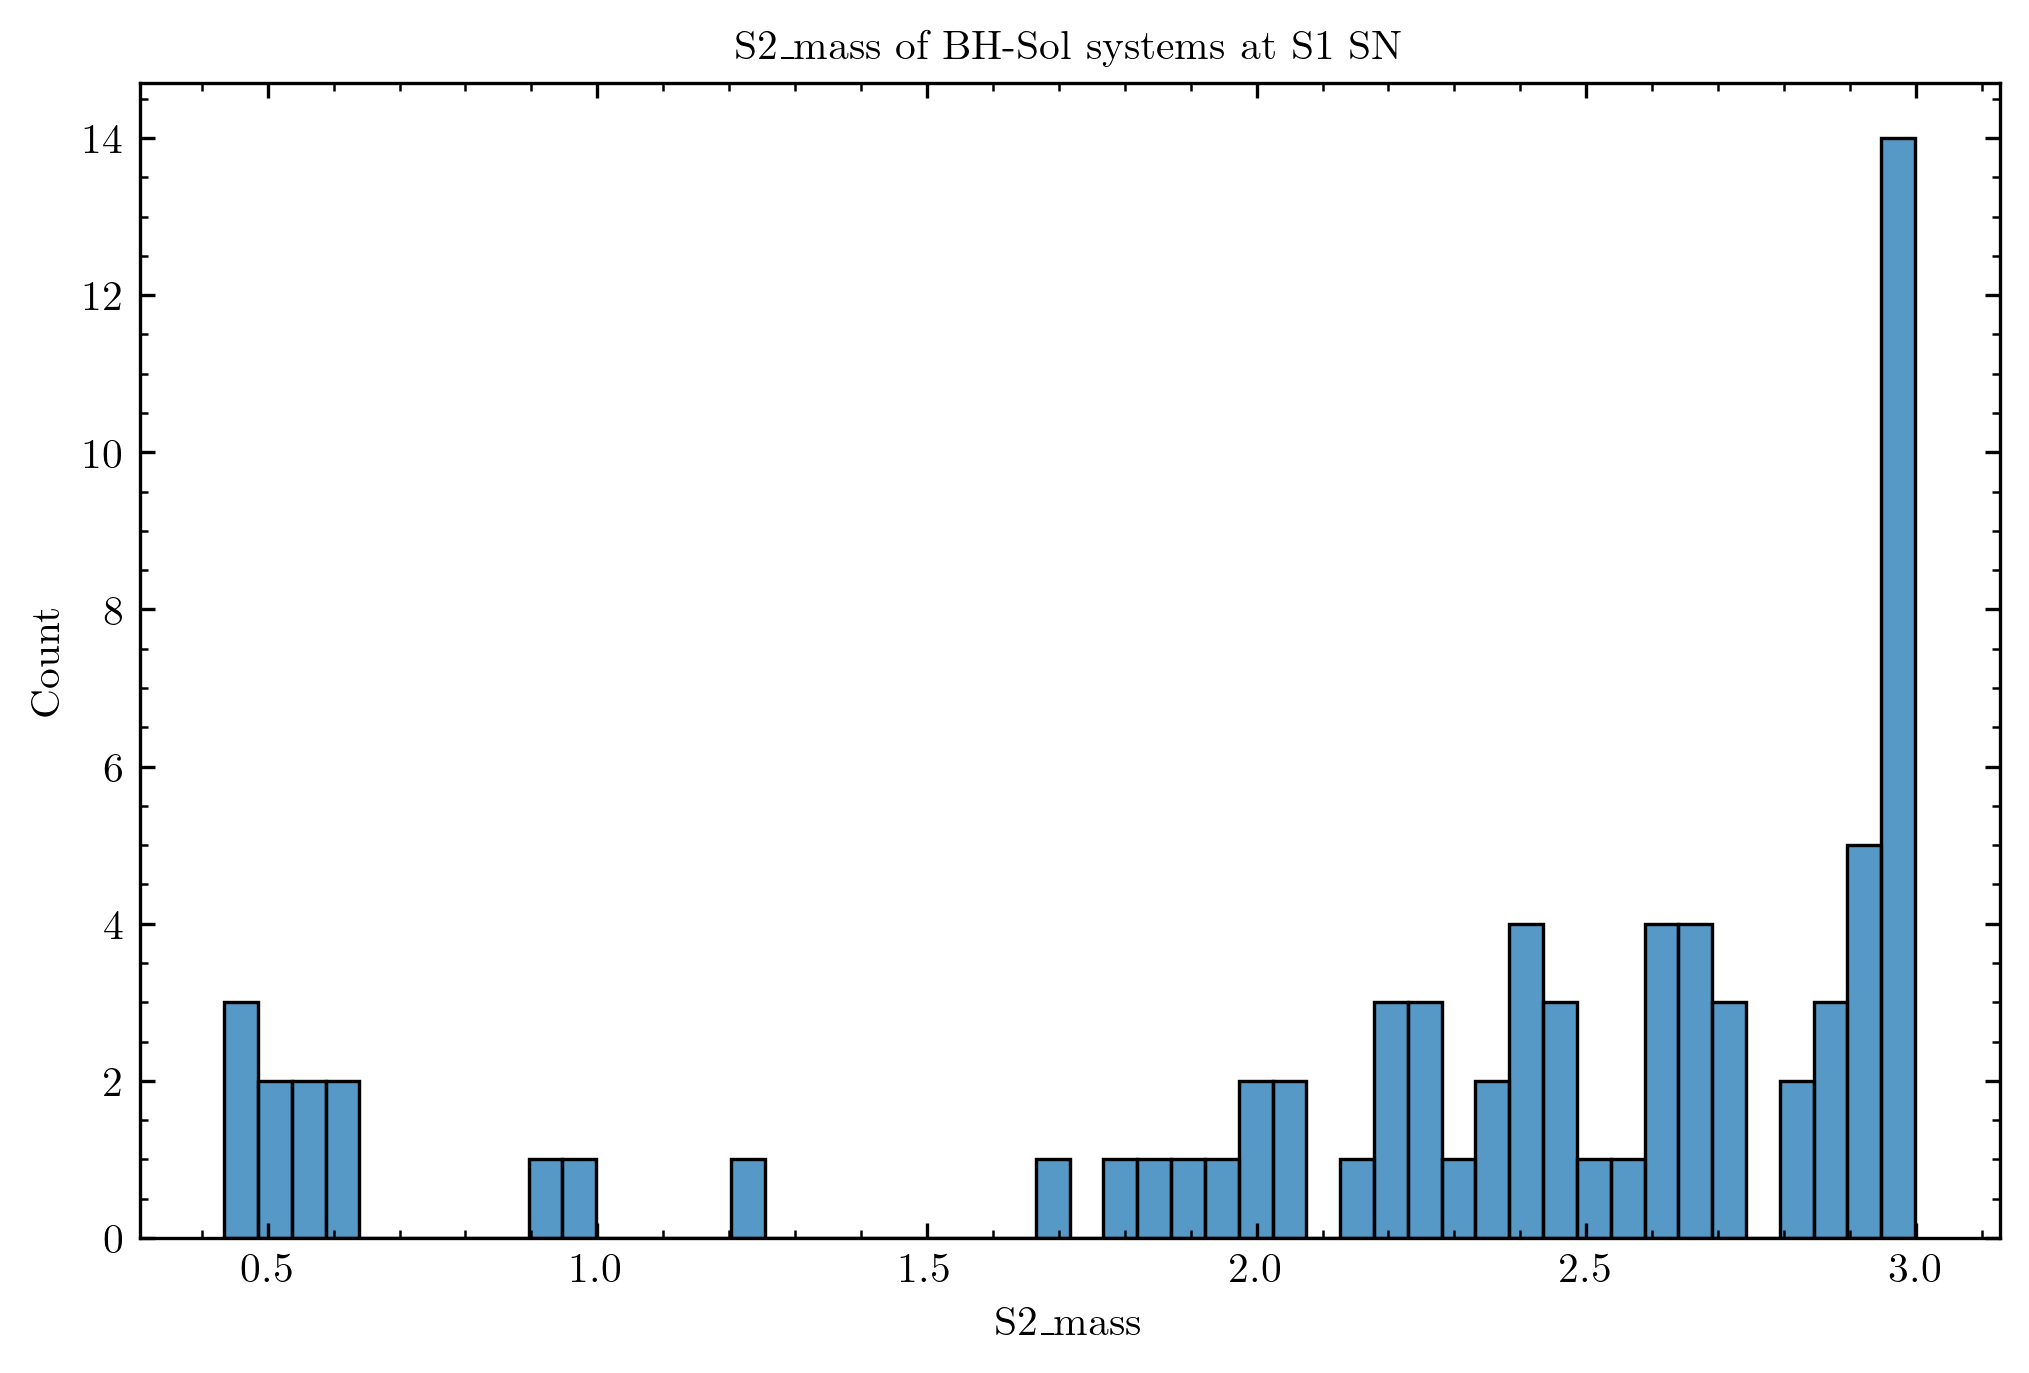

In [75]:
basicColHist(bhSolRows,'S2_mass')

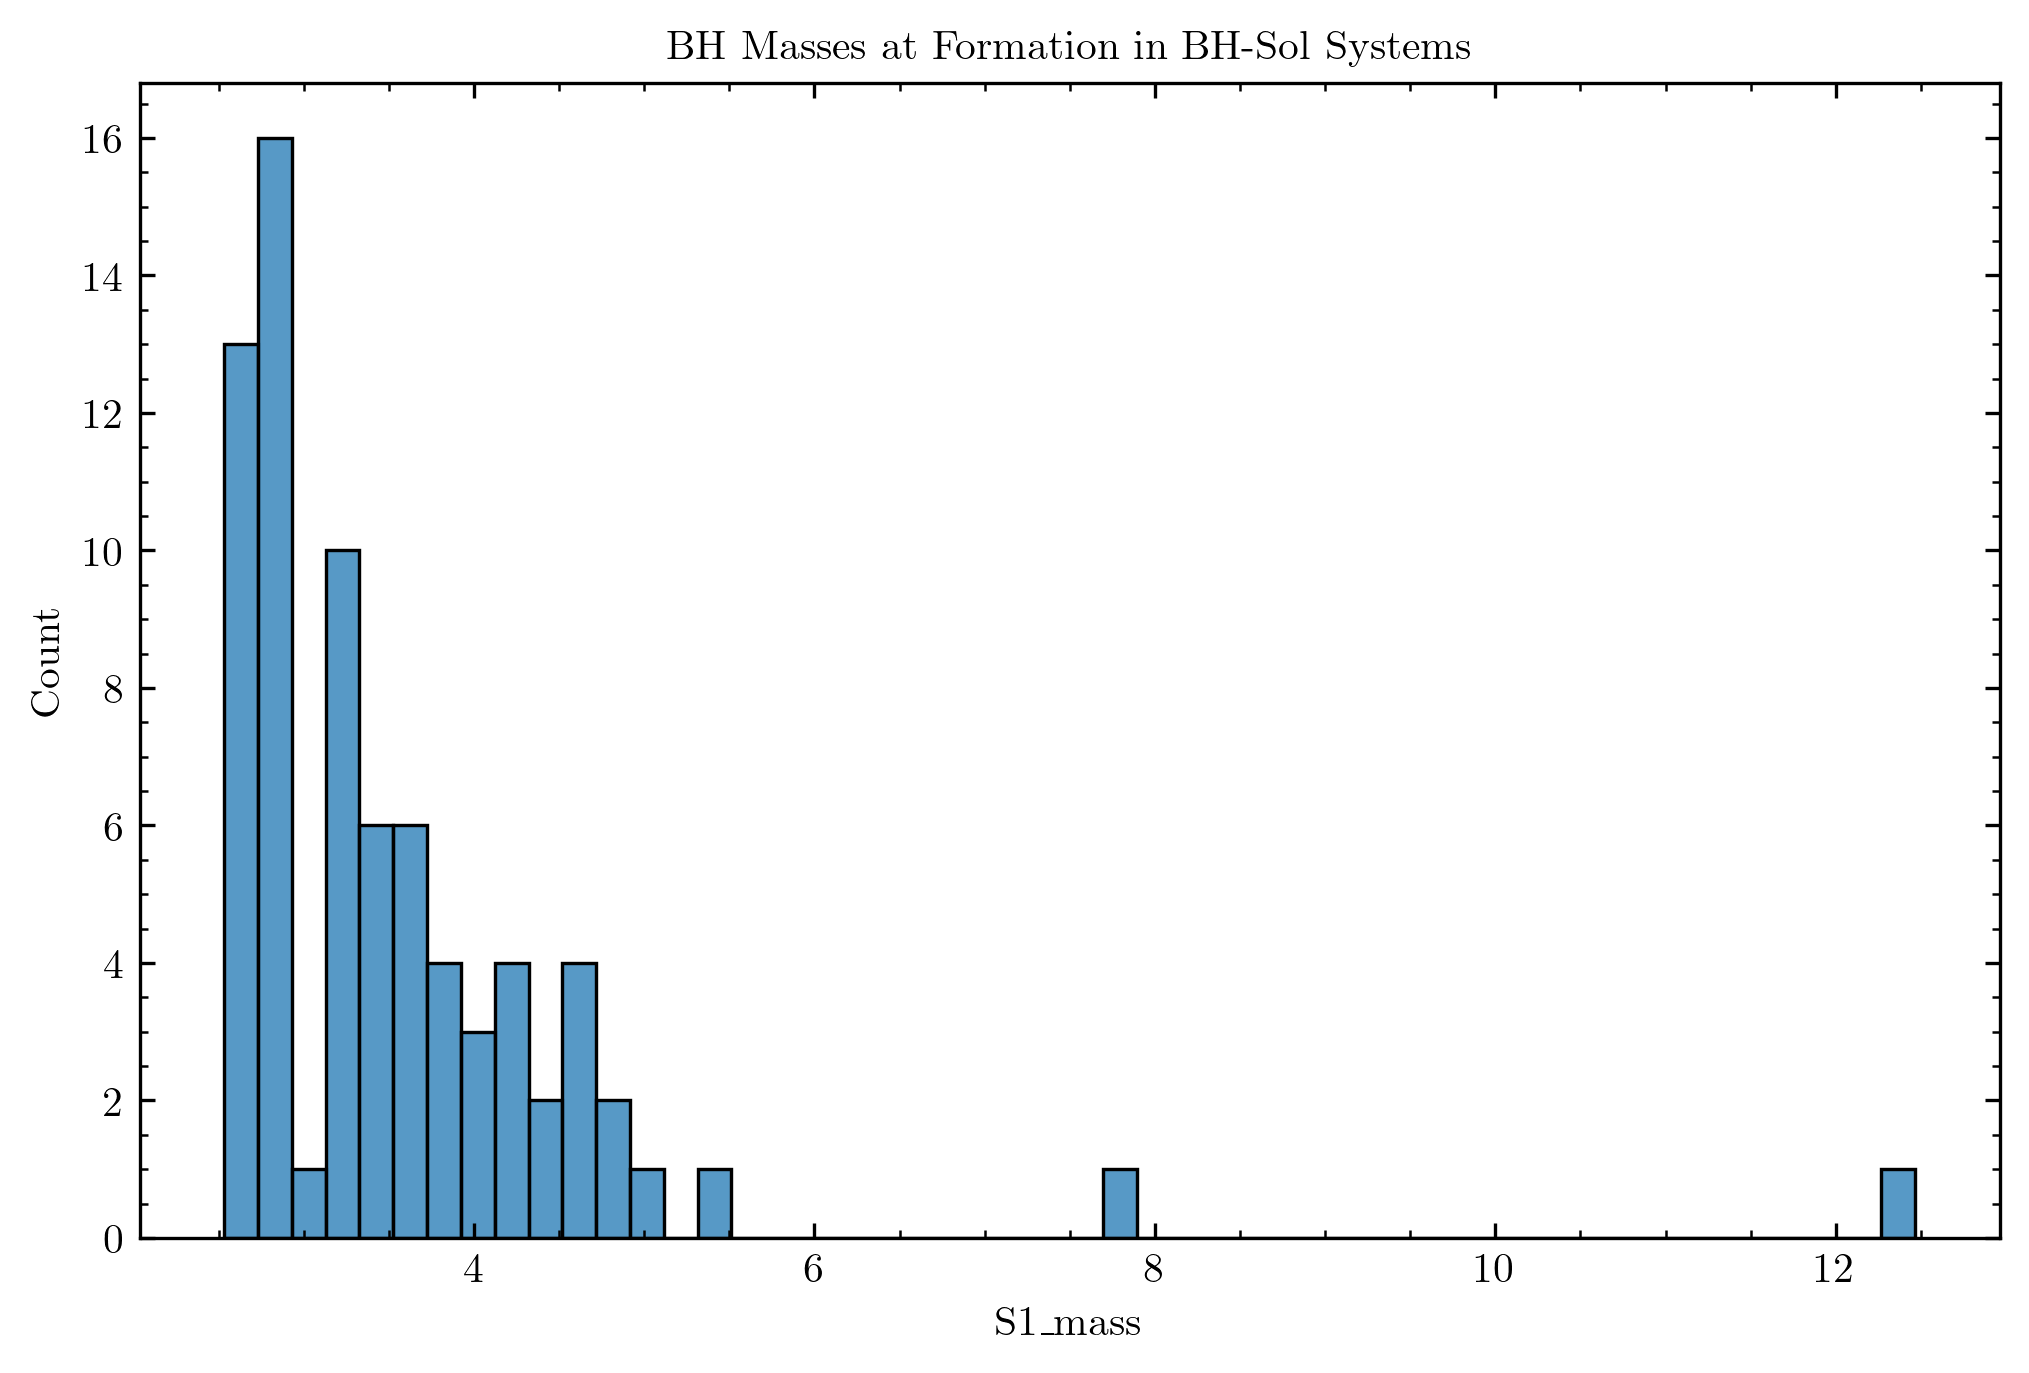

In [76]:
basicColHist(bhSolRows,'S1_mass', title='BH Masses at Formation in BH-Sol Systems')

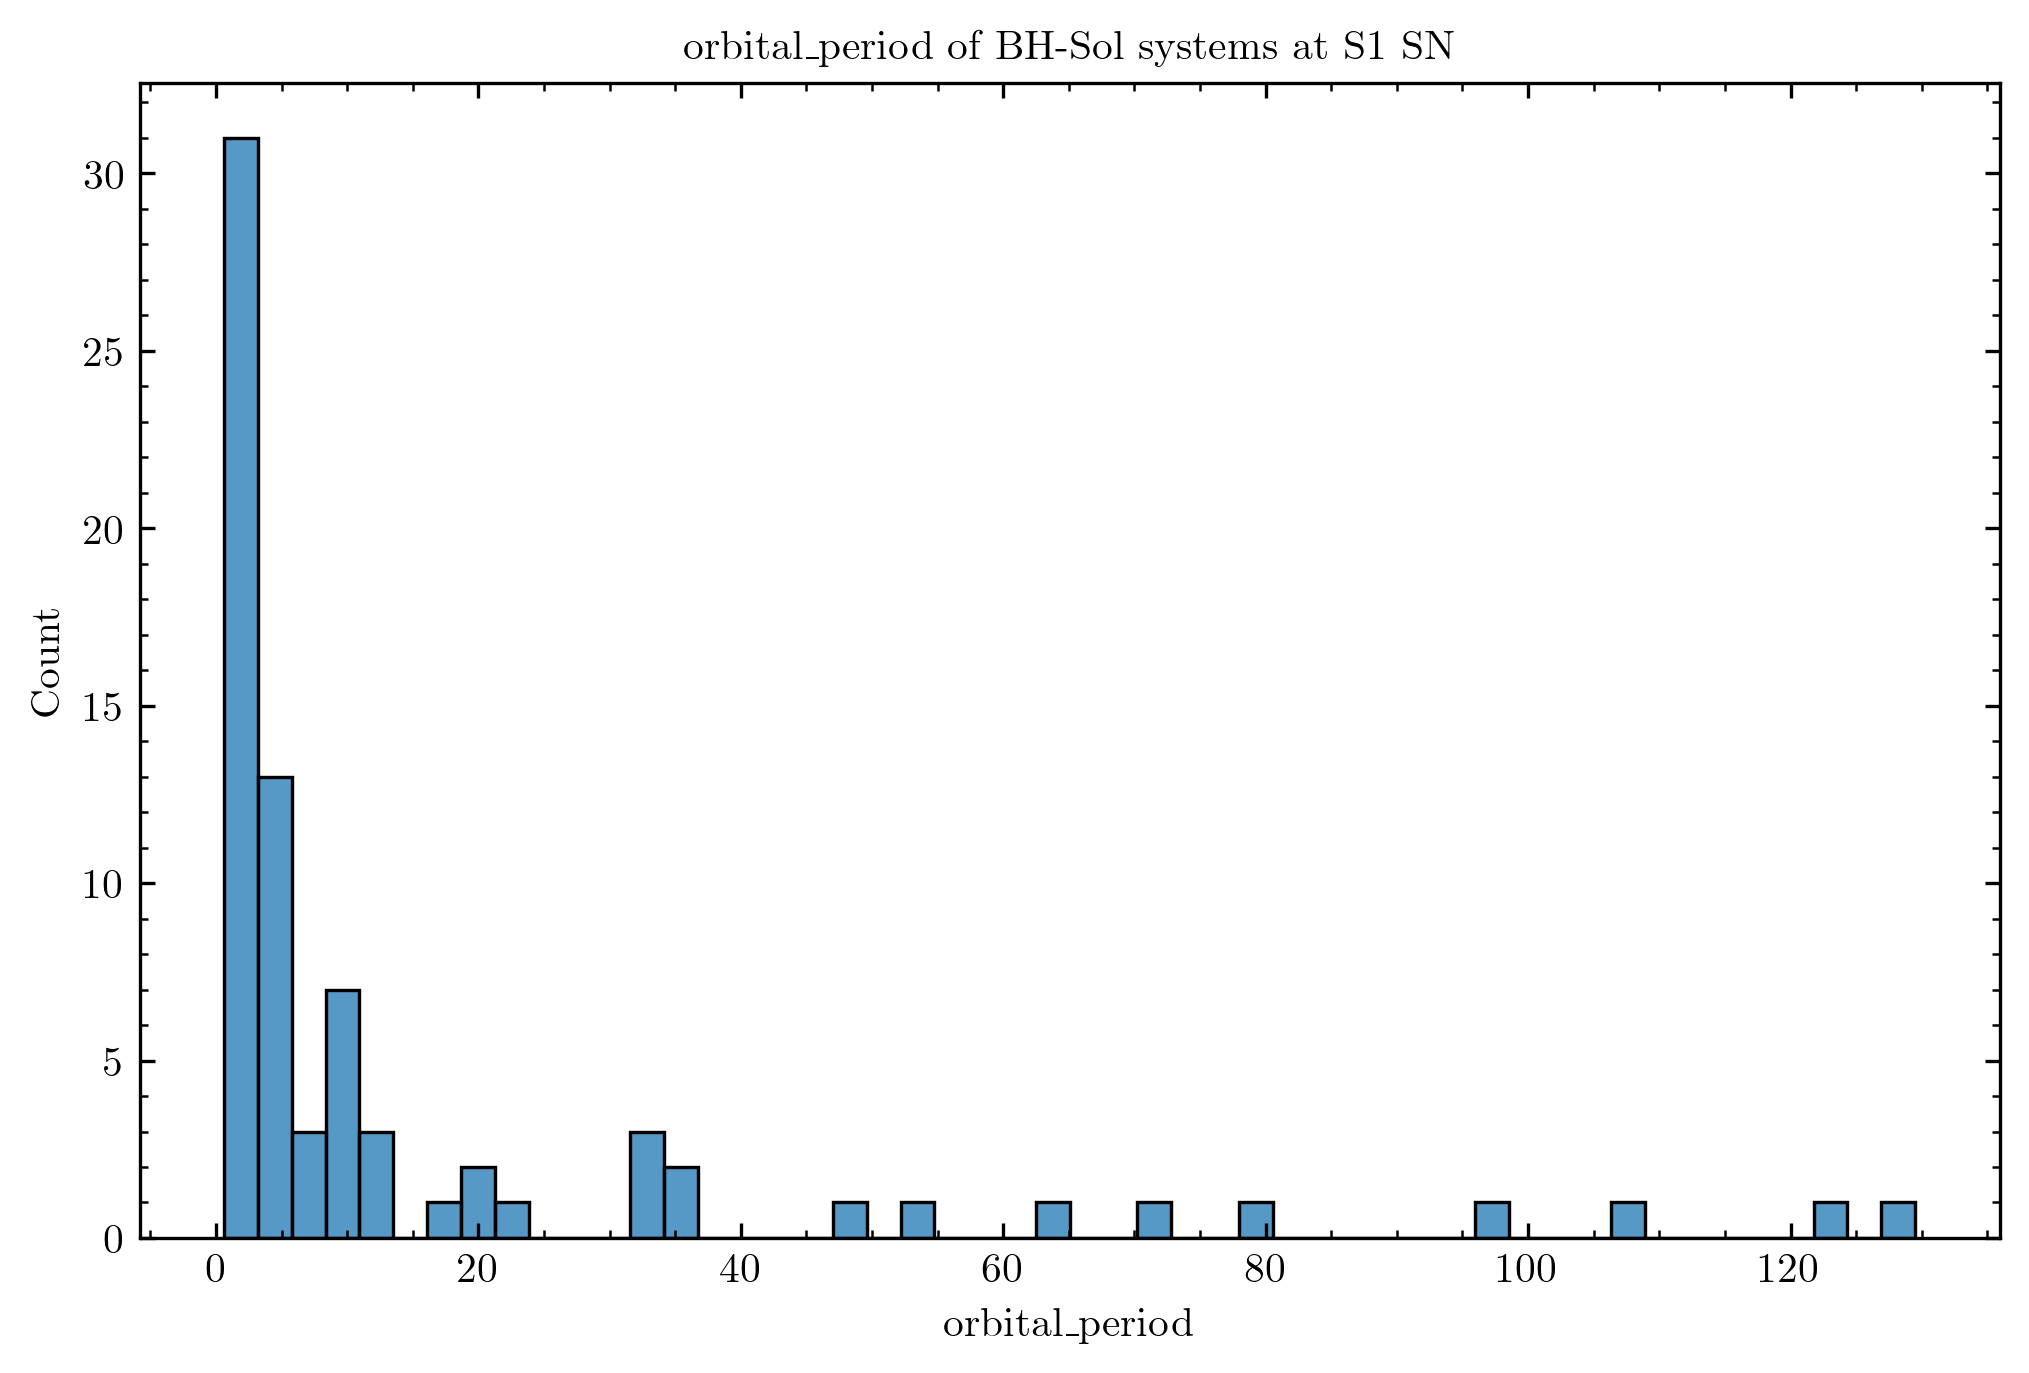

In [77]:
basicColHist(bhSolRows,'orbital_period', saveFig=True, savePath=graphSave)

In [78]:
slimOP = bhSolRows[bhSolRows['orbital_period'] < 25]['orbital_period']

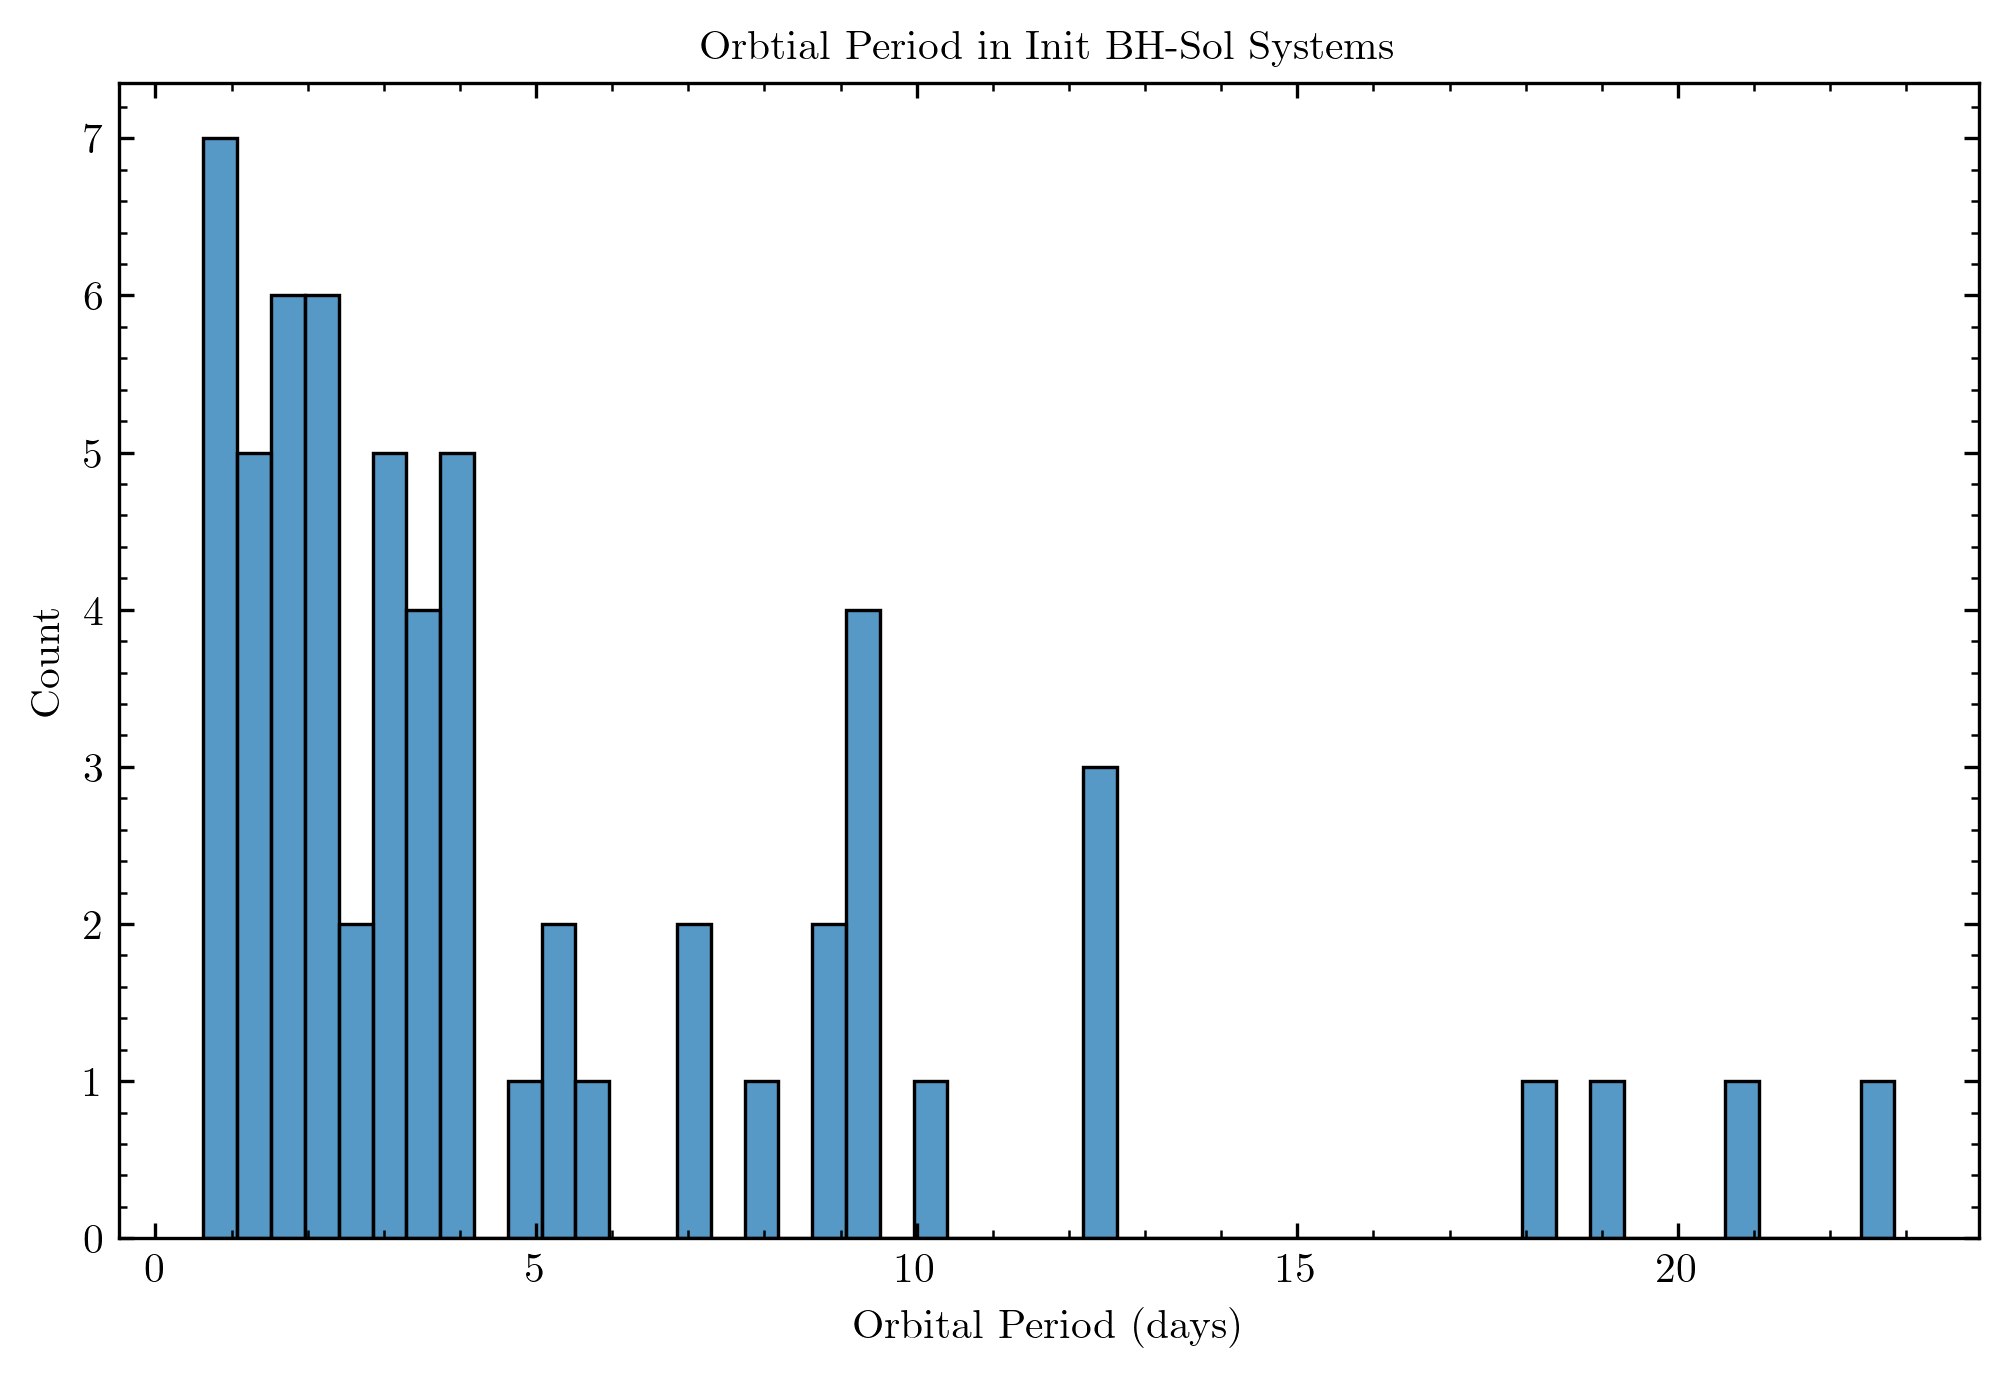

In [79]:
genVarHist(slimOP, title='Orbtial Period in Init BH-Sol Systems', xLabel='Orbital Period (days)', saveFig=True, savePath=graphSave)

In [80]:
# HR_Diagram(bhSolRows,
#            'BhSol',
#            Star_Radius=15)

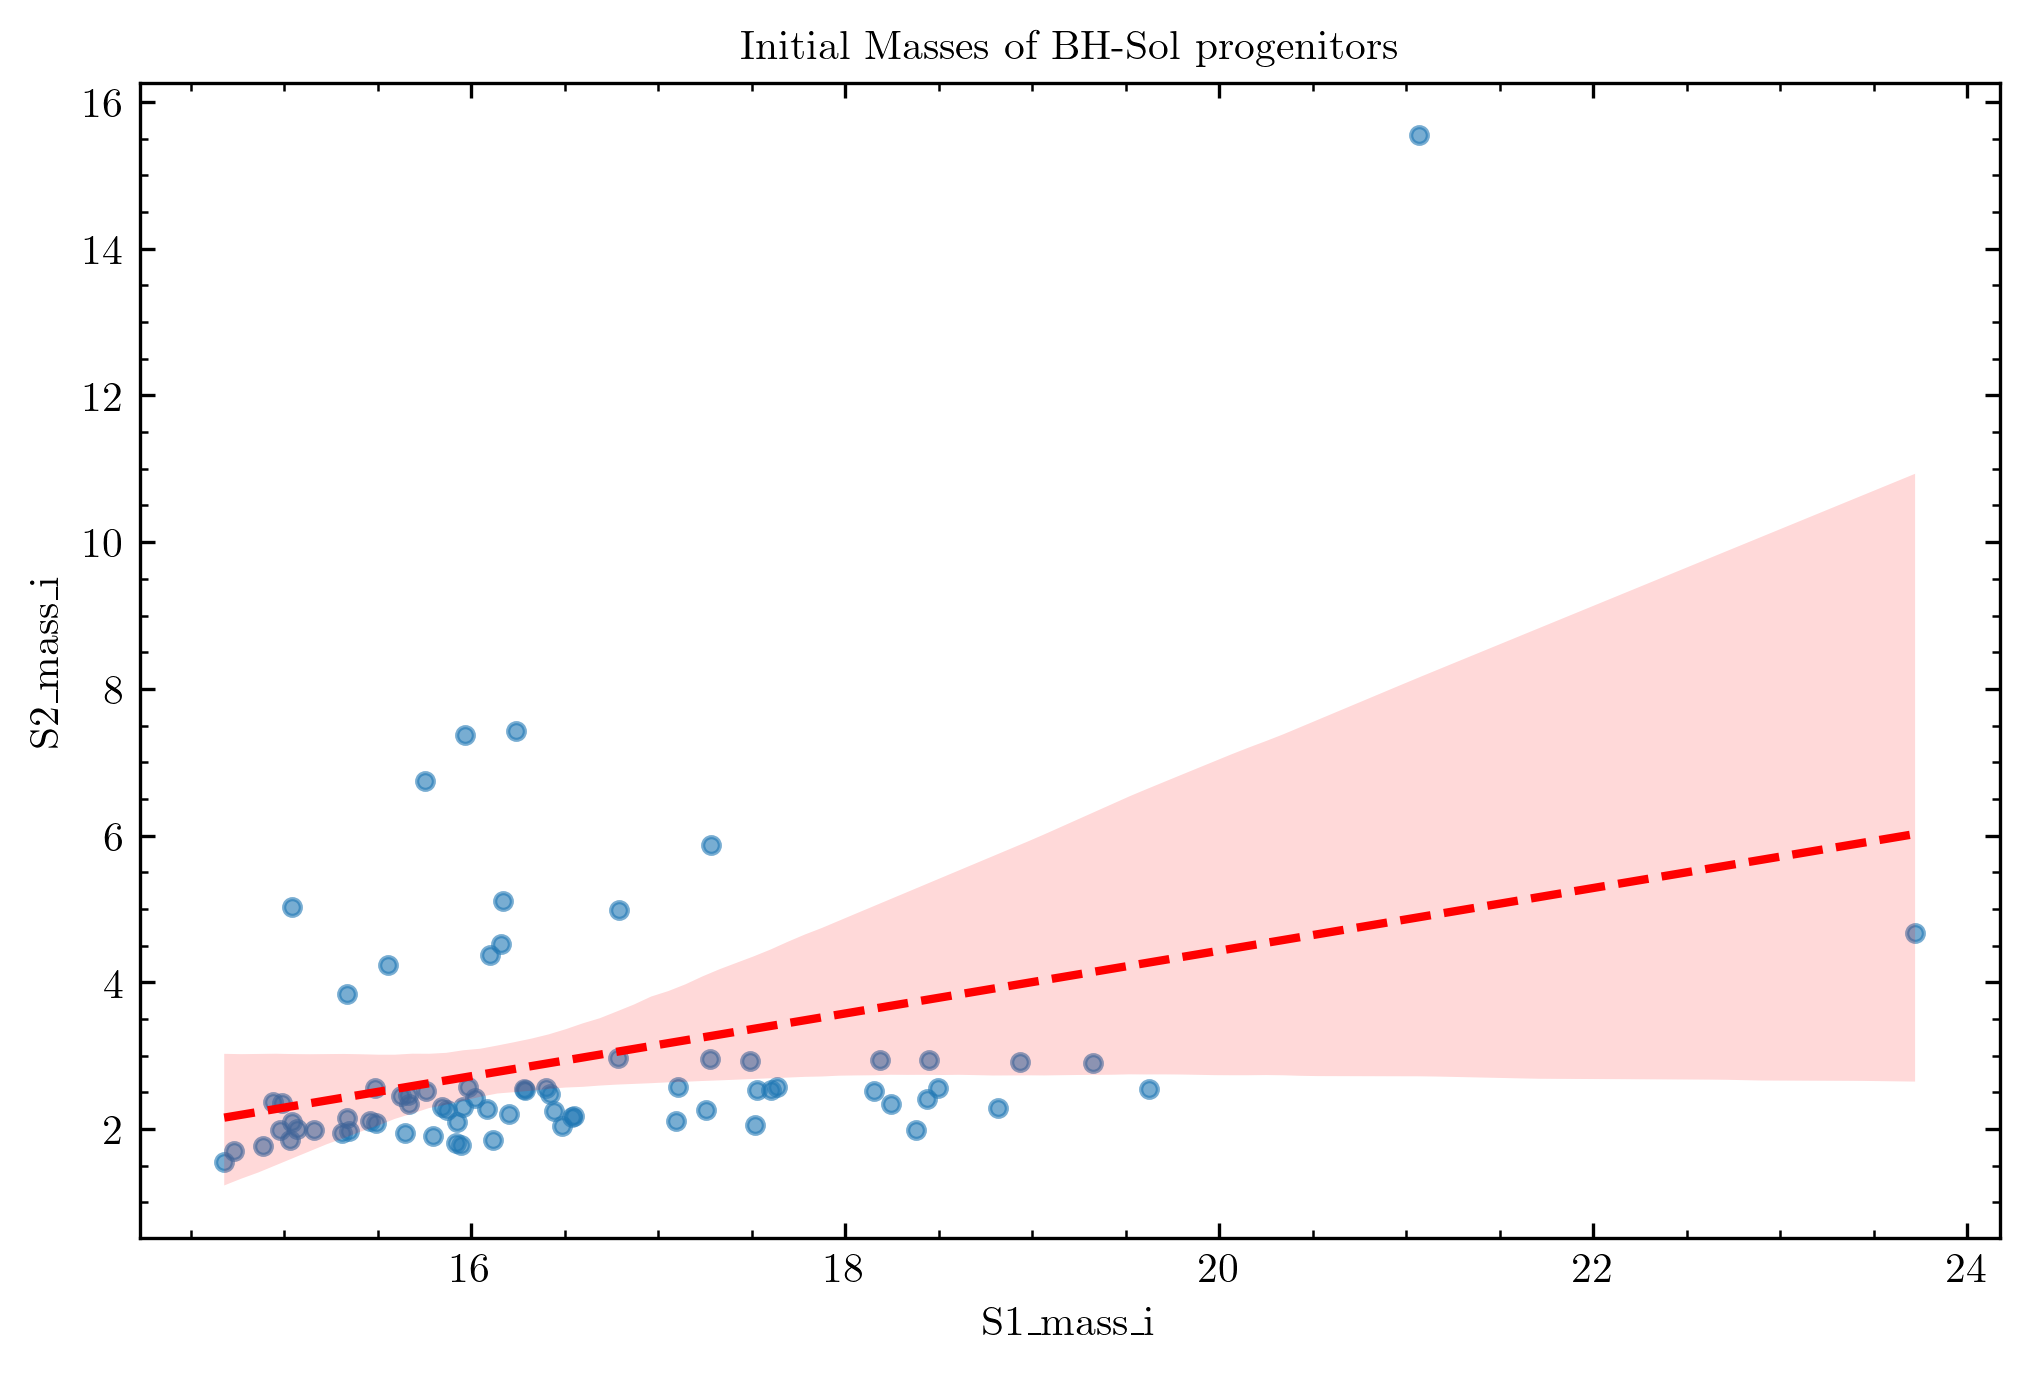

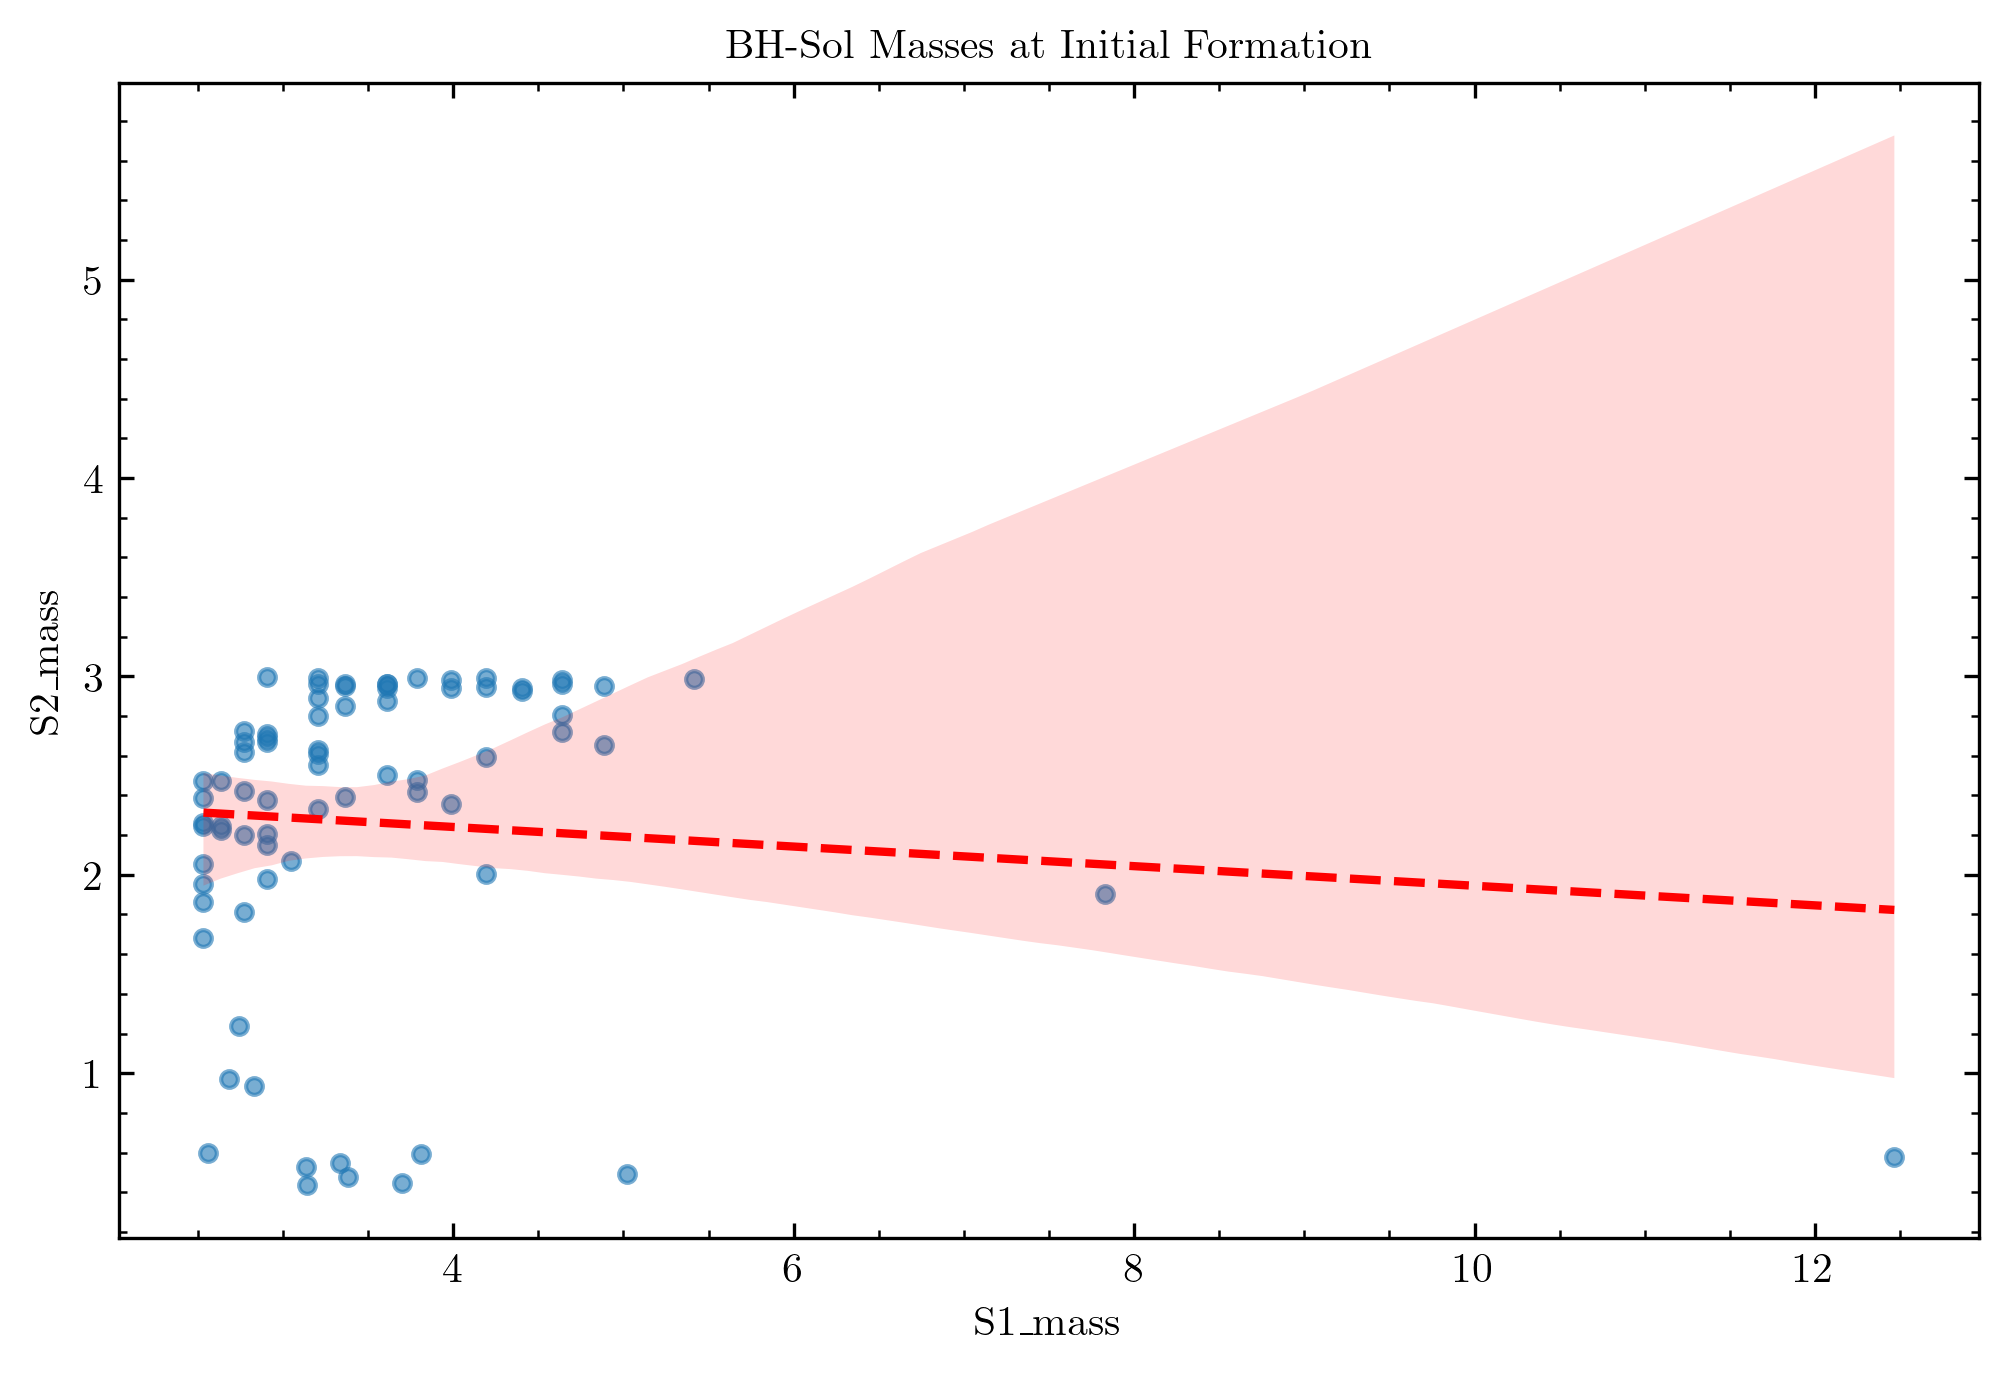

In [81]:
xVsY(df = pOneline, xvar= 'S1_mass_i', yvar='S2_mass_i', title='Initial Masses of BH-Sol progenitors', fit=True, saveFig=False, savePath=graphSave)

xVsY(df = bhSolRows, xvar= 'S1_mass', yvar='S2_mass', title='BH-Sol Masses at Initial Formation', fit=True, saveFig=False, savePath=graphSave)

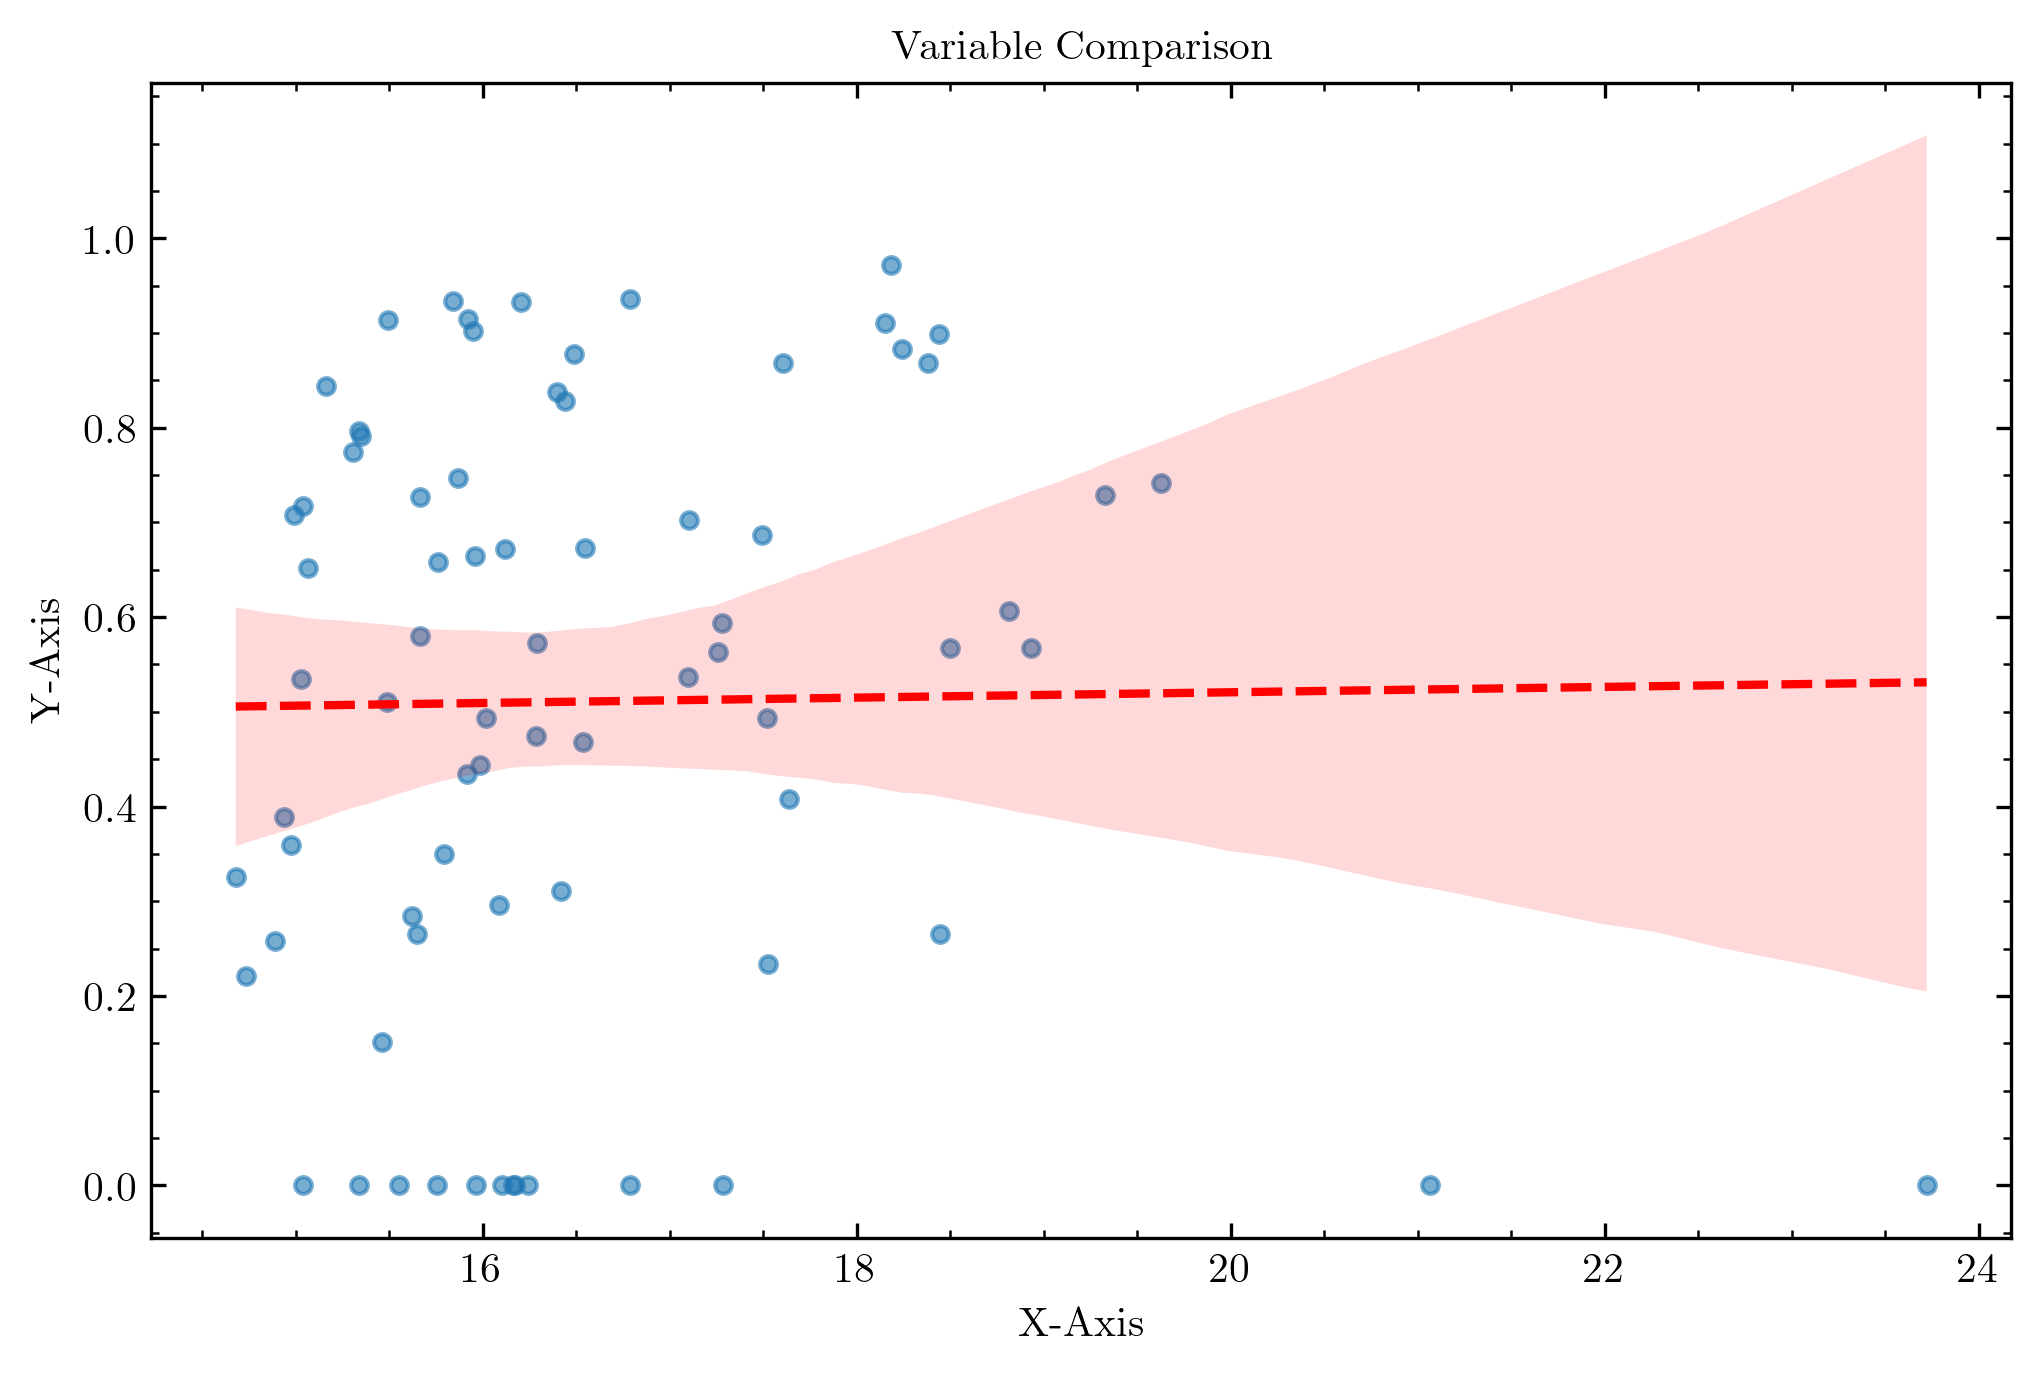

In [82]:
xVsY(useDF=False, xvar=pOneline['S1_mass_i'], yvar=bhSolRows['eccentricity'], fit=True)

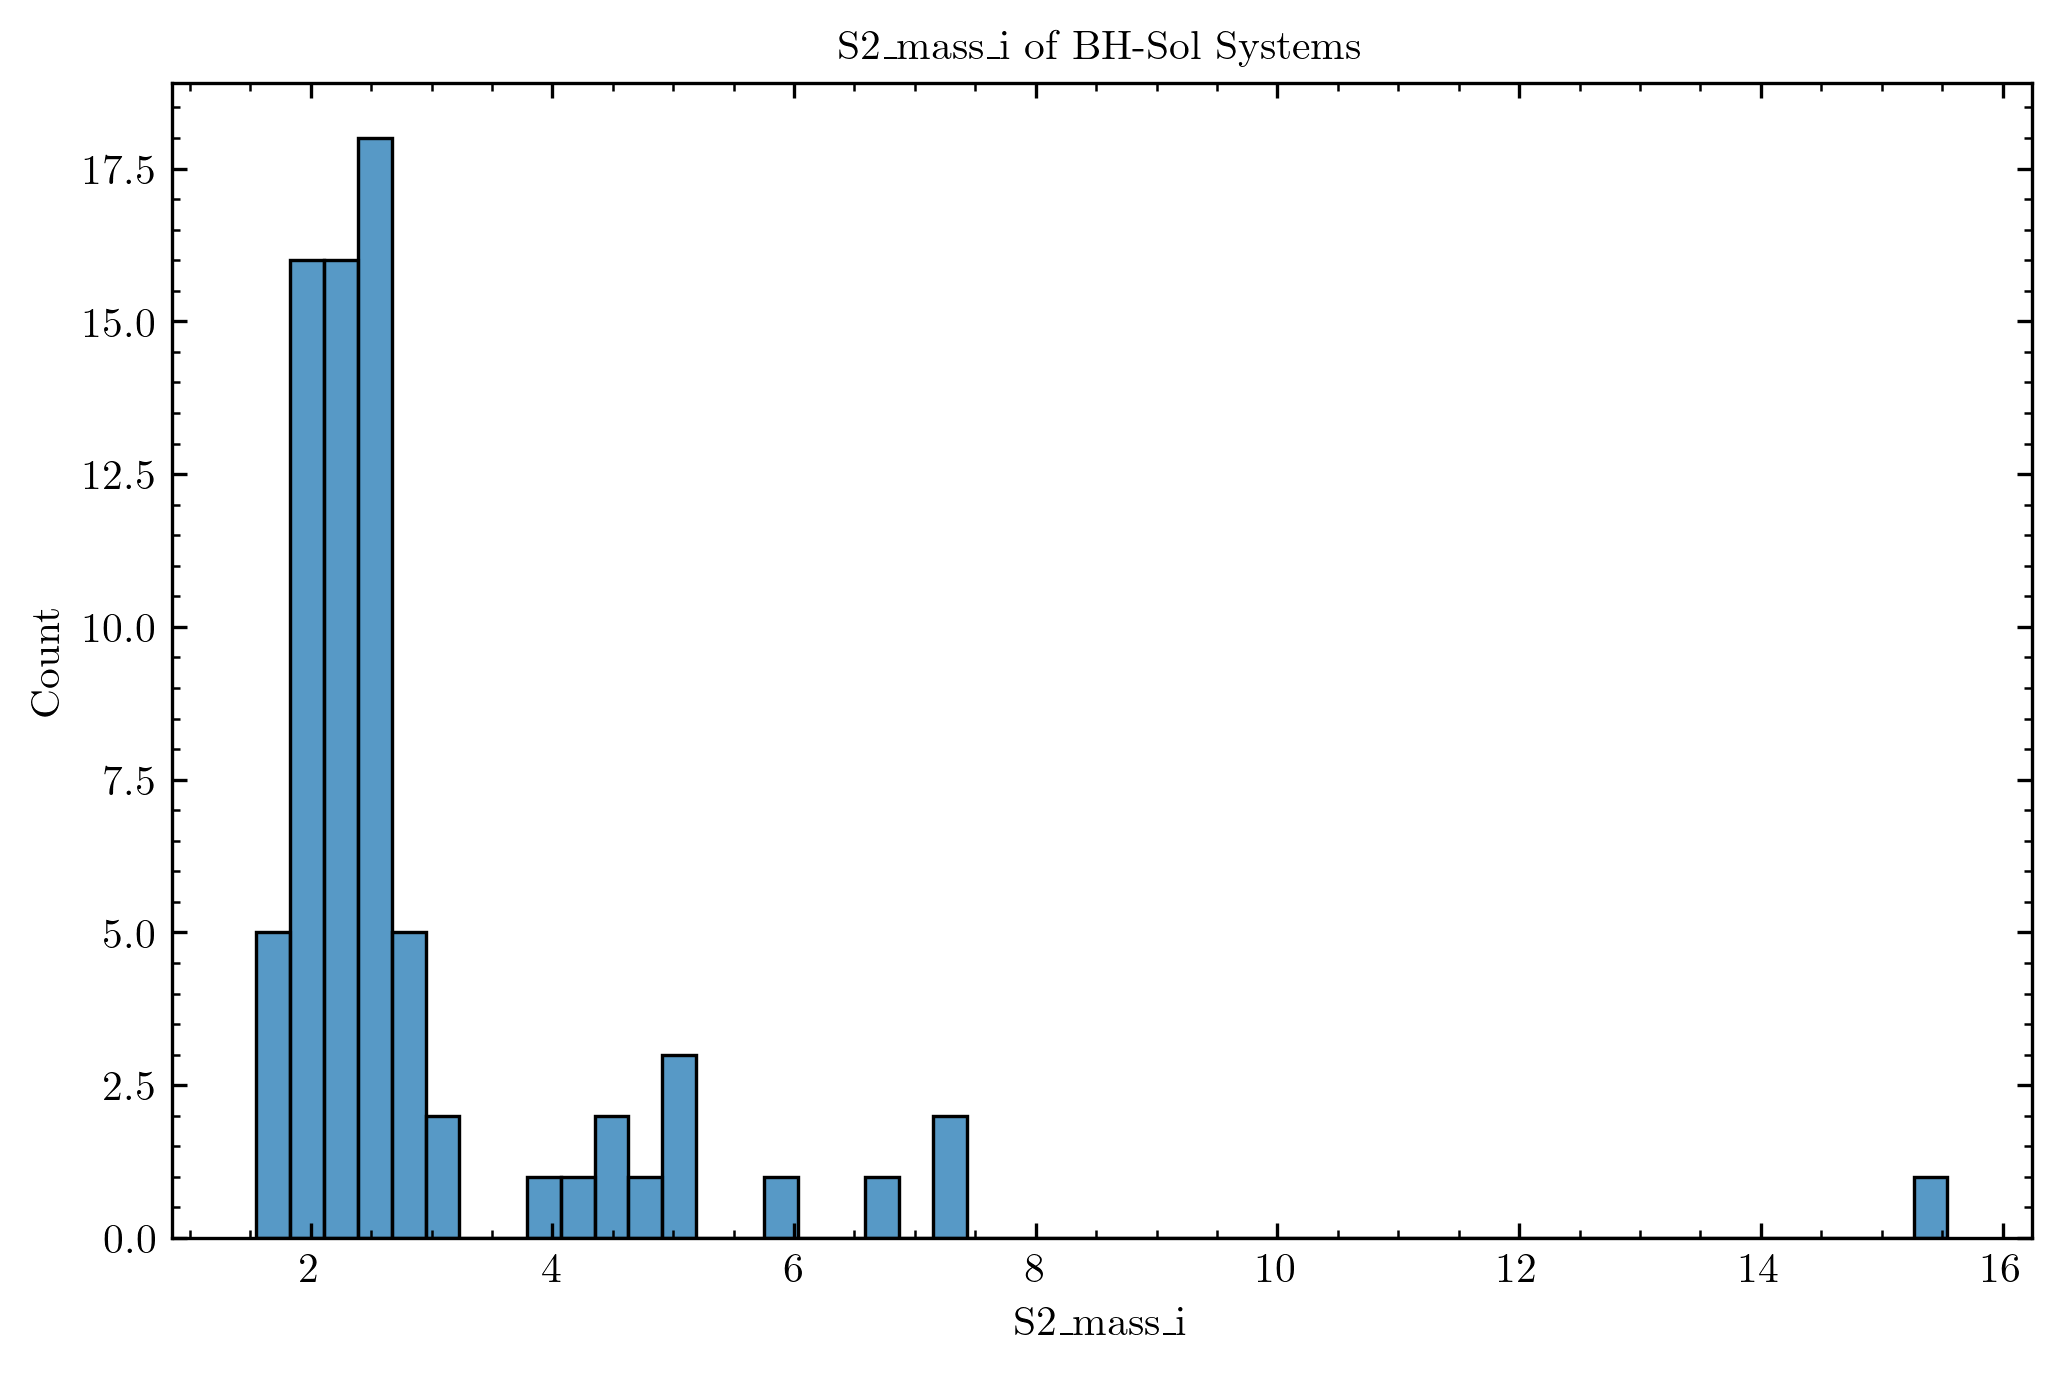

In [83]:
fig, ax = plt.subplots(figsize=(8,5))

var = 'S2_mass_i'
sns.histplot(pOneline[var], bins=50, ax=ax)

title = f'{var} of BH-Sol Systems'

ax.set_title(title)
ax.set_xlabel(var)
ax.set_ylabel('Count')

clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
plt.savefig(graphSave / clean_name, bbox_inches='tight')

plt.show()

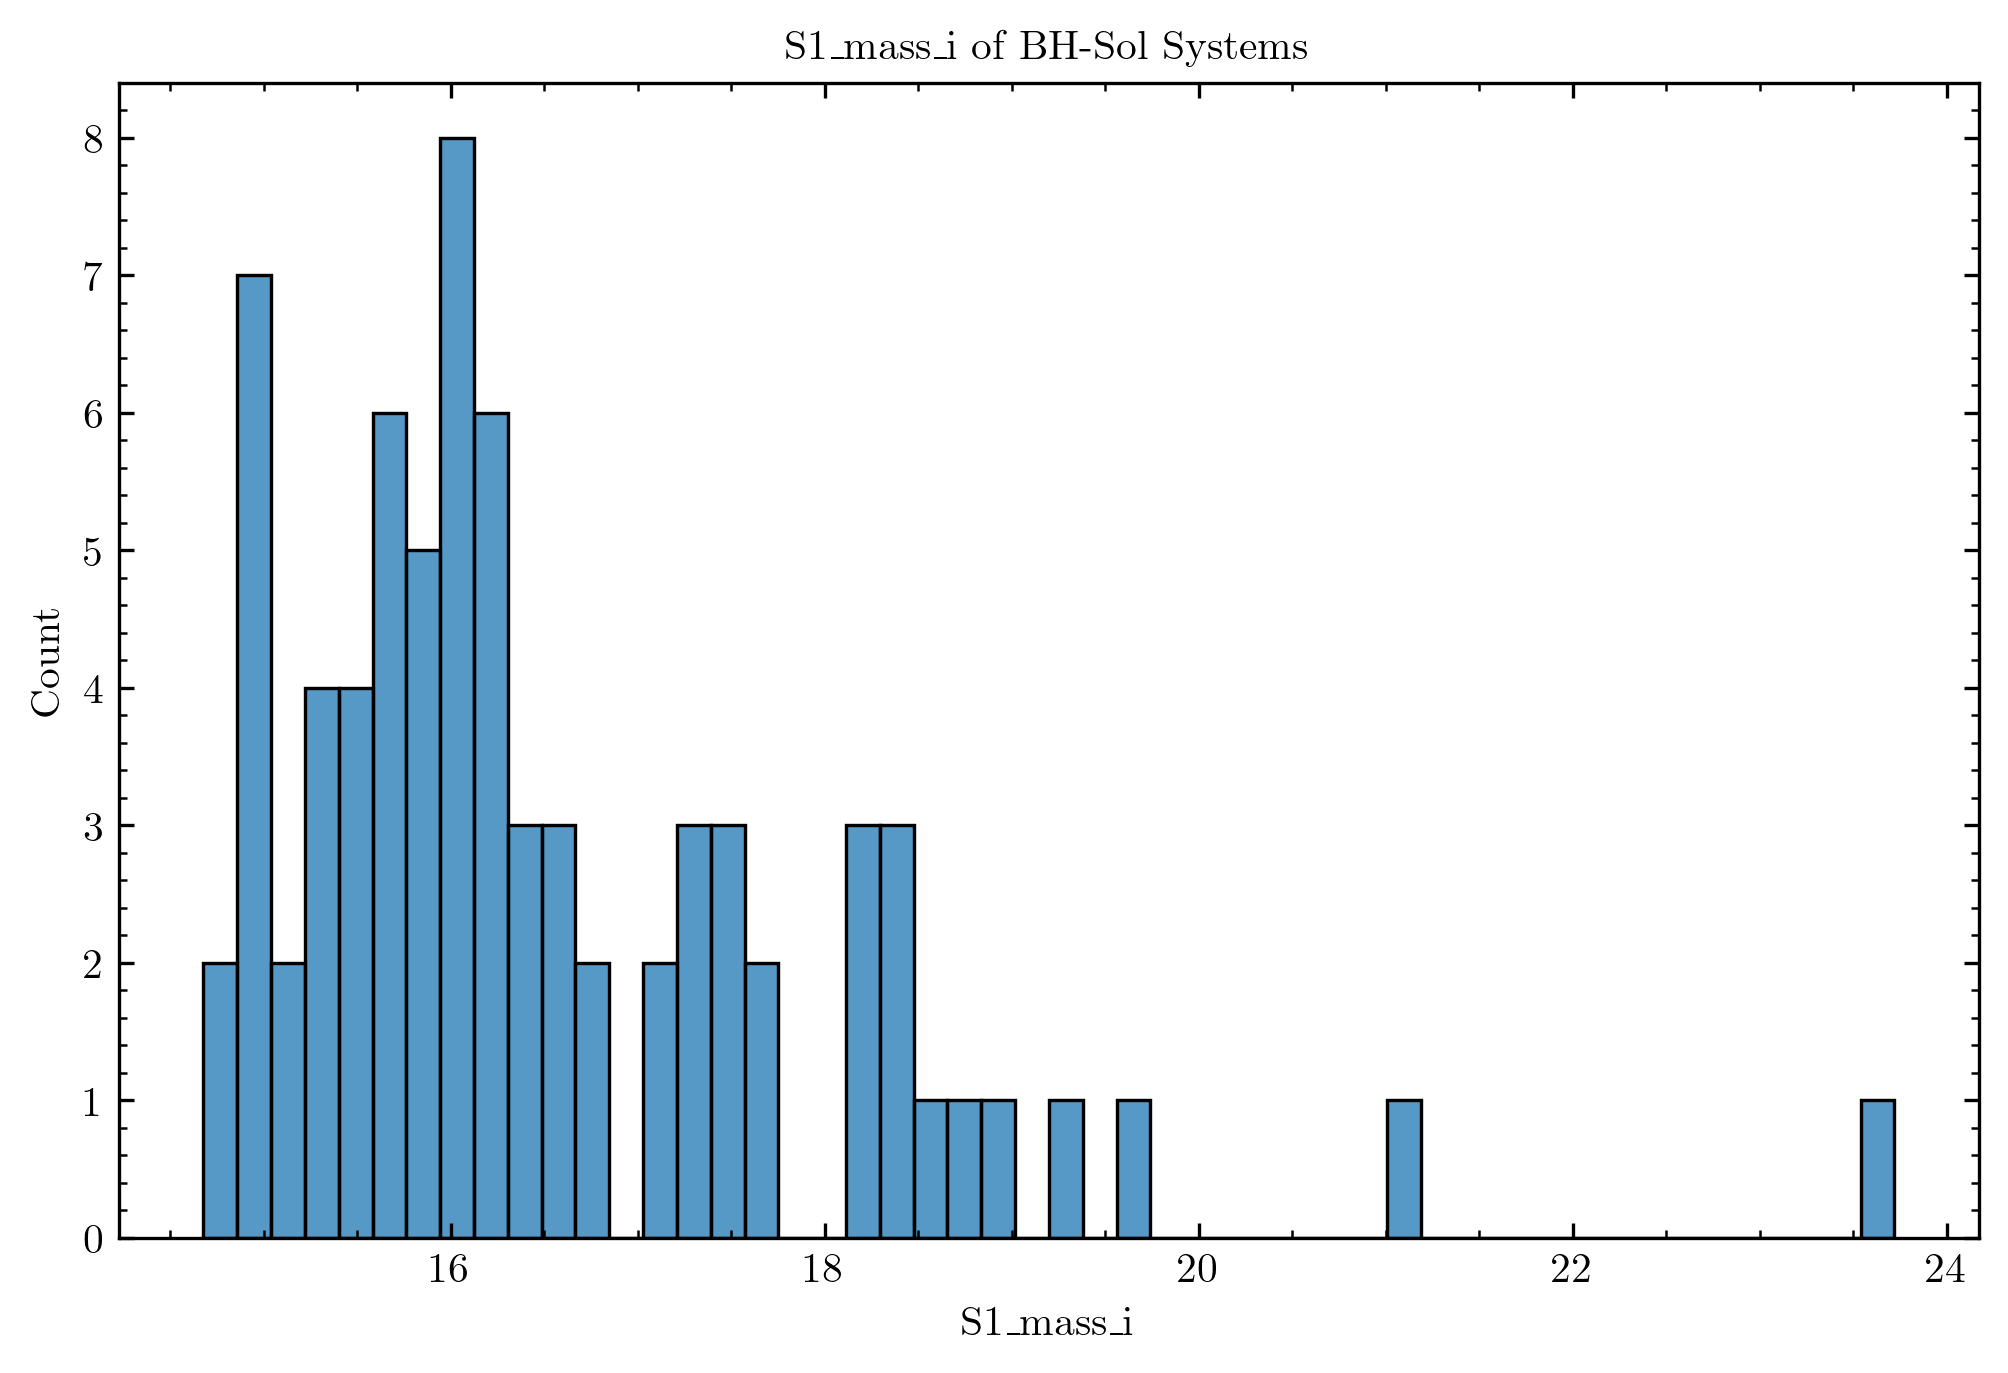

In [84]:
fig, ax = plt.subplots(figsize=(8,5))

var = 'S1_mass_i'
sns.histplot(pOneline[var], bins=50, ax=ax)

title = f'{var} of BH-Sol Systems'

ax.set_title(title)
ax.set_xlabel(var)
ax.set_ylabel('Count')

clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
plt.savefig(graphSave / clean_name, bbox_inches='tight')

plt.show()